# Notebook 1: Data Loading and Preprocessing
## EEEM073 – AI and Sustainability | University of Surrey
### Project: Spatiotemporal Wildfire Severity Forecasting
### Dataset: ESA Fire_cci v5.1 MODIS Grid Product (2017–2022)

**Objectives of this notebook:**
1. Load the full 6-year ESA Fire_cci NetCDF dataset using memory-efficient lazy loading.
2. Inspect the dataset structure, dimensions, and variables.
3. Crop to a high-fire-density region (Central Africa) to manage compute resources.
4. Mask non-burnable pixels to remove noise from the target variable.
5. Perform a chronological train/validation/test split (no random shuffling — required for time-series).
6. Fit normalization parameters on the training set only to prevent data leakage.
7. Save processed splits as Zarr stores for use in subsequent notebooks.

**UNSDGs addressed:** Goal 13 (Climate Action), Goal 15 (Life on Land)

---
## 1. Install and Import Dependencies

In [16]:
# Install required packages (run once on HPC; comment out after first run)
import sys
!{sys.executable} -m pip install xarray netcdf4 dask[complete] zarr numpy pandas matplotlib cartopy --quiet

In [17]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')
print(f'xarray version: {xr.__version__}')
print(f'numpy version: {np.__version__}')

All libraries imported successfully.
xarray version: 2025.6.1
numpy version: 2.2.6


---
## 2. Load the Full Dataset

The ESA Fire_cci v5.1 dataset is distributed as monthly NetCDF files (~72 files for 2017–2022).
We use `xr.open_mfdataset()` with Dask to load them lazily — meaning data is not read into RAM
until explicitly requested. This is essential for handling the full ~7GB dataset on the HPC.

In [18]:
# ── UPDATE THIS PATH to your HPC data directory ──
DATA_PATH = r'C:\Users\Ishaque\OneDrive\Documents\GitHub\Sustainable-Wildfire-Prediction-AI\dataset'  # e.g. '/scratch/username/fire_cci/'
OUTPUT_PATH = './processed/'                # Where to save Zarr outputs
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load all .nc files in the directory using Dask for lazy evaluation.
# concat_dim='time' stacks monthly files along the time axis.
# chunks={'time': 12} processes one year at a time to stay within RAM limits.
ds = xr.open_mfdataset(
    os.path.join(DATA_PATH, '*.nc'),
    combine='by_coords',
    chunks={'time': 12, 'lat': 90, 'lon': 180},
    engine='netcdf4'
)

print('Dataset loaded successfully (lazy / Dask-backed).')
print(ds)

Dataset loaded successfully (lazy / Dask-backed).
<xarray.Dataset> Size: 7GB
Dimensions:                          (time: 72, lat: 720, nv: 2, lon: 1440,
                                      vegetation_class: 18)
Coordinates:
  * lat                              (lat) float32 3kB 89.88 89.62 ... -89.88
  * lon                              (lon) float32 6kB -179.9 -179.6 ... 179.9
  * time                             (time) datetime64[ns] 576B 2017-01-01 .....
  * vegetation_class                 (vegetation_class) int32 72B 10 20 ... 180
Dimensions without coordinates: nv
Data variables:
    lat_bnds                         (time, lat, nv) float32 415kB dask.array<chunksize=(1, 90, 2), meta=np.ndarray>
    lon_bnds                         (time, lon, nv) float32 829kB dask.array<chunksize=(1, 180, 2), meta=np.ndarray>
    time_bnds                        (time, nv) datetime64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vegetation_class_name            (time, vegetation_cl

---
## 3. Initial Inspection

Before any preprocessing, we inspect the dataset to understand its structure.
This forms the basis of the 'Data Dictionary' required in the report (Section 1).

In [19]:
# Print core dimensions and their sizes
print('=== Dataset Dimensions ===')
for dim, size in ds.dims.items():
    print(f'  {dim}: {size}')

print('\n=== Time Range ===')
print(f'  Start: {pd.Timestamp(ds.time.values[0])}')
print(f'  End:   {pd.Timestamp(ds.time.values[-1])}')
print(f'  Total months: {len(ds.time)}')

print('\n=== Spatial Resolution ===')
print(f'  Lat range: {float(ds.lat.min()):.2f} to {float(ds.lat.max()):.2f}')
print(f'  Lon range: {float(ds.lon.min()):.2f} to {float(ds.lon.max()):.2f}')
print(f'  Grid: {len(ds.lat)} lat x {len(ds.lon)} lon (0.25-degree resolution)')

=== Dataset Dimensions ===
  time: 72
  lat: 720
  nv: 2
  lon: 1440
  vegetation_class: 18

=== Time Range ===
  Start: 2017-01-01 00:00:00
  End:   2022-12-01 00:00:00
  Total months: 72

=== Spatial Resolution ===
  Lat range: -89.88 to 89.88
  Lon range: -179.88 to 179.88
  Grid: 720 lat x 1440 lon (0.25-degree resolution)


In [20]:
# Print vegetation class names — important for SHAP interpretation in Notebook 4.
# Each class represents a land-cover type (e.g. broadleaf forest, grassland, cropland).
print('=== 18 Vegetation / Land-Cover Classes ===')
veg_names = ds['vegetation_class_name'].isel(time=0).values
veg_ids   = ds['vegetation_class'].values
for vid, vname in zip(veg_ids, veg_names):
    print(f'  Class {vid}: {vname.decode("utf-8").strip()}')

=== 18 Vegetation / Land-Cover Classes ===
  Class 10: Cropland, rainfed
  Class 20: Cropland, irrigated or post-flooding
  Class 30: Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)
  Class 40: Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)
  Class 50: Tree cover, broadleaved, evergreen, closed to open (>15%)
  Class 60: Tree cover, broadleaved, deciduous, closed to open (>15%)
  Class 70: Tree cover, needleleaved, evergreen, closed to open (>15%)
  Class 80: Tree cover, needleleaved, deciduous, closed to open (>15%)
  Class 90: Tree cover, mixed leaf type (broadleaved and needleleaved)
  Class 100: Mosaic tree and shrub (>50%) / herbaceous cover (<50%)
  Class 110: Mosaic herbaceous cover (>50%) / tree and shrub (<50%)
  Class 120: Shrubland
  Class 130: Grassland
  Class 140: Lichens and mosses
  Class 150: Sparse vegetation (tree, shrub, herbaceous cover) (<15%)
  Class 160: Tree cover, flooded, fresh or brakish 

In [21]:
# Summarise all data variables — used as the Data Dictionary in the report.
print('=== Data Variables (Data Dictionary) ===')
print(f'{"Variable":<35} {"Dimensions":<40} {"DType"}')
print('-' * 90)
for var in ds.data_vars:
    v = ds[var]
    print(f'{var:<35} {str(v.dims):<40} {v.dtype}')

=== Data Variables (Data Dictionary) ===
Variable                            Dimensions                               DType
------------------------------------------------------------------------------------------
lat_bnds                            ('time', 'lat', 'nv')                    float32
lon_bnds                            ('time', 'lon', 'nv')                    float32
time_bnds                           ('time', 'nv')                           datetime64[ns]
vegetation_class_name               ('time', 'vegetation_class')             |S150
burned_area                         ('time', 'lat', 'lon')                   float32
standard_error                      ('time', 'lat', 'lon')                   float32
fraction_of_burnable_area           ('time', 'lat', 'lon')                   float32
fraction_of_observed_area           ('time', 'lat', 'lon')                   float32
number_of_patches                   ('time', 'lat', 'lon')                   float32
burned_area_in_

---
## 4. Data Quality Check

We check for missing values and quantify sparsity in the target variable (`burned_area`).
High sparsity (most pixels = 0) is an important characteristic to report — it explains
why simple regression baselines struggle and motivates the use of a time-series model.

In [22]:
# Count NaN values — using Dask so only the sum is computed, not the full array
nan_count   = int(ds['burned_area'].isnull().sum().compute())
zero_count  = int((ds['burned_area'] == 0).sum().compute())
total_pixels = ds['burned_area'].size

print(f'Total pixels (time x lat x lon): {total_pixels:,}')
print(f'Missing (NaN) values:            {nan_count:,}  ({100*nan_count/total_pixels:.2f}%)')
print(f'Zero-fire pixels:                {zero_count:,}  ({100*zero_count/total_pixels:.2f}%)')
print(f'Non-zero fire pixels:            {total_pixels-zero_count:,}  ({100*(total_pixels-zero_count)/total_pixels:.2f}%)')

# Key insight: ~98.8% of pixels have zero burned area.
# This extreme sparsity is a defining challenge of this dataset.
# We will address it during modelling (log-transform + focus on fire-active regions).

Total pixels (time x lat x lon): 74,649,600
Missing (NaN) values:            0  (0.00%)
Zero-fire pixels:                73,753,849  (98.80%)
Non-zero fire pixels:            895,751  (1.20%)


---
## 5. Region Selection: Central Africa

We focus on **Central Africa (lat: -20° to 10°N, lon: 10° to 45°E)**.

**Justification:**  
Central Africa consistently accounts for the largest share of global burned area
(approximately 60–70% of annual global fire emissions, per ESA Fire_cci reports).
Focusing here:
- Maximises the proportion of non-zero target values (reduces sparsity from ~98.8% globally)
- Keeps the dataset computationally tractable on the HPC without sacrificing scientific relevance
- Allows direct alignment with SDG 15 (Life on Land) for African savanna ecosystems

In [23]:
# Crop to Central Africa bounding box.
# Note: lat must be sliced high-to-low because the dataset stores lat descending.
LAT_MAX, LAT_MIN =  10.0, -20.0
LON_MIN, LON_MAX =  10.0,  45.0

ds_region = ds.sel(
    lat=slice(LAT_MAX, LAT_MIN),
    lon=slice(LON_MIN, LON_MAX)
)

print(f'Cropped dataset dimensions:')
print(f'  Time: {len(ds_region.time)} months')
print(f'  Lat:  {len(ds_region.lat)} grid points ({LAT_MIN}° to {LAT_MAX}°N)')
print(f'  Lon:  {len(ds_region.lon)} grid points ({LON_MIN}° to {LON_MAX}°E)')

# Verify the burn signal is higher in this region
nonzero_region = int((ds_region['burned_area'] > 0).sum().compute())
total_region   = ds_region['burned_area'].size
print(f'\nRegional non-zero fire pixels: {100*nonzero_region/total_region:.2f}%  (vs. {100*(total_pixels-zero_count)/total_pixels:.2f}% globally)')

Cropped dataset dimensions:
  Time: 72 months
  Lat:  120 grid points (-20.0° to 10.0°N)
  Lon:  140 grid points (10.0° to 45.0°E)

Regional non-zero fire pixels: 21.50%  (vs. 1.20% globally)


---
## 6. Data Cleaning: Mask Non-Burnable Pixels

The `fraction_of_burnable_area` variable identifies pixels that are physically capable of burning
(i.e. not open ocean, permanent ice, or bare rock). Pixels with < 1% burnable fraction are
masked out — they cannot produce meaningful fire signal and would add noise to the model.

In [24]:
BURNABLE_THRESHOLD = 0.01  # Pixels with < 1% burnable area are excluded

# Apply mask: pixels below threshold become NaN across all variables
ds_masked = ds_region.where(ds_region['fraction_of_burnable_area'] > BURNABLE_THRESHOLD)

# Confirm masking effect
remaining = int(ds_masked['burned_area'].notnull().sum().compute())
original  = int(ds_region['burned_area'].notnull().sum().compute())
print(f'Pixels before masking: {original:,}')
print(f'Pixels after masking:  {remaining:,}')
print(f'Pixels removed:        {original - remaining:,}  ({100*(original-remaining)/original:.1f}%)')

Pixels before masking: 1,209,600
Pixels after masking:  1,039,608
Pixels removed:        169,992  (14.1%)


---
## 7. Feature Engineering

We create two additional features to help the models learn temporal structure:

1. **Month** — an integer (1–12) that captures within-year seasonality.
2. **Sin/Cos month encoding** — converts month to a circular representation so that
   December (12) and January (1) are understood as adjacent, not distant.
   This is a standard technique for cyclic time features and improves LSTM performance.

We also apply a **log1p transform** to `burned_area` to compress the extreme right skew
(a small number of pixels have very large fire values that would dominate training).

In [25]:
# ── Cyclic month encoding ──────────────────────────────────────────────────
# Extract month as integer from the time coordinate
month_vals = ds_masked['time.month'].values  # shape: (72,)

# Broadcast to (time, lat, lon) so it can be stored as a data variable
month_arr  = xr.DataArray(
    month_vals,
    coords={'time': ds_masked.time},
    dims=['time']
)

ds_masked = ds_masked.assign({
    'month':       month_arr,
    'month_sin':   np.sin(2 * np.pi * month_arr / 12),   # captures cyclical seasonality
    'month_cos':   np.cos(2 * np.pi * month_arr / 12),
})

# ── Log1p transform on target variable ────────────────────────────────────
# log1p(x) = log(1 + x) handles zeros gracefully (log(0) is undefined)
ds_masked = ds_masked.assign({
    'burned_area_log': np.log1p(ds_masked['burned_area'])
})

print('Feature engineering complete.')
print('New features added: month, month_sin, month_cos, burned_area_log')

Feature engineering complete.
New features added: month, month_sin, month_cos, burned_area_log


---
## 8. Chronological Train / Validation / Test Split

**Critical rule for time series:** we must split by time, never randomly.
Random splitting would allow the model to 'see the future' during training, causing
artificially inflated evaluation scores that do not reflect real-world performance.

Split:
- **Train:** Jan 2017 – Jun 2021 (54 months, ~75%)
- **Validation:** Jul 2021 – Dec 2021 (6 months, ~8%)
- **Test:** Jan 2022 – Dec 2022 (12 months, ~17%)

The test set covers an entire calendar year, ensuring all seasonal patterns are represented.

In [26]:
# Chronological split indices (72 total months: Jan 2017 – Dec 2022)
TRAIN_END = 54   # index 0–53  → Jan 2017 – Jun 2021
VAL_END   = 60   # index 54–59 → Jul 2021 – Dec 2021
# Test       = index 60–71 → Jan 2022 – Dec 2022

ds_train = ds_masked.isel(time=slice(0,        TRAIN_END))
ds_val   = ds_masked.isel(time=slice(TRAIN_END, VAL_END))
ds_test  = ds_masked.isel(time=slice(VAL_END,   None))


print('=== Data Split Summary ===')
print(f'Train:      {len(ds_train.time)} months  '
      f'({pd.Timestamp(ds_train.time.values[0]).strftime("%b %Y")} – '
      f'{pd.Timestamp(ds_train.time.values[-1]).strftime("%b %Y")})')
print(f'Validation: {len(ds_val.time)} months  '
      f'({pd.Timestamp(ds_val.time.values[0]).strftime("%b %Y")} – '
      f'{pd.Timestamp(ds_val.time.values[-1]).strftime("%b %Y")})')
print(f'Test:       {len(ds_test.time)} months  '
      f'({pd.Timestamp(ds_test.time.values[0]).strftime("%b %Y")} – '
      f'{pd.Timestamp(ds_test.time.values[-1]).strftime("%b %Y")})')

=== Data Split Summary ===
Train:      54 months  (Jan 2017 – Jun 2021)
Validation: 6 months  (Jul 2021 – Dec 2021)
Test:       12 months  (Jan 2022 – Dec 2022)


---
## 9. Normalisation (Leak-Free)

We normalise the log-transformed burned area to [0, 1] using **min-max scaling**.

**Important:** the min and max values are computed from the **training set only**.
These same values are then applied to the validation and test sets.
Computing statistics from the full dataset before splitting (data leakage) would
allow the model to implicitly 'know' future values during training — invalidating results.

In [27]:
# Compute min and max from TRAINING SET ONLY
ba_log_min = float(ds_train['burned_area_log'].min().compute())
ba_log_max = float(ds_train['burned_area_log'].max().compute())

print(f'Training set stats (burned_area_log):')
print(f'  Min: {ba_log_min:.4f}')
print(f'  Max: {ba_log_max:.4f}')

def minmax_scale(da, vmin, vmax):
    """
    Apply min-max normalisation using pre-computed statistics.
    
    Parameters
    ----------
    da   : xr.DataArray  Input data array
    vmin : float         Minimum value (from training set)
    vmax : float         Maximum value (from training set)
    
    Returns
    -------
    xr.DataArray scaled to [0, 1] using training statistics
    """
    return (da - vmin) / (vmax - vmin + 1e-8)  # 1e-8 avoids division by zero

# Apply the same scaling to all three splits
ds_train = ds_train.assign({'target_norm': minmax_scale(ds_train['burned_area_log'], ba_log_min, ba_log_max)})
ds_val   = ds_val.assign(  {'target_norm': minmax_scale(ds_val['burned_area_log'],   ba_log_min, ba_log_max)})
ds_test  = ds_test.assign( {'target_norm': minmax_scale(ds_test['burned_area_log'],  ba_log_min, ba_log_max)})

# Save the scaling parameters so we can inverse-transform predictions later
np.save(os.path.join(OUTPUT_PATH, 'norm_params.npy'),
        np.array([ba_log_min, ba_log_max]))

print('\nNormalisation applied (leak-free). Parameters saved to norm_params.npy')

Training set stats (burned_area_log):
  Min: 0.0000
  Max: 20.4284

Normalisation applied (leak-free). Parameters saved to norm_params.npy


---
## 10. Preview: Monthly Burned Area Time Series

A quick sanity-check plot showing the total burned area summed over the Central Africa
region for each month. This confirms the dataset has loaded correctly and reveals the
strong dry-season fire peaks (typically July–October in this region).

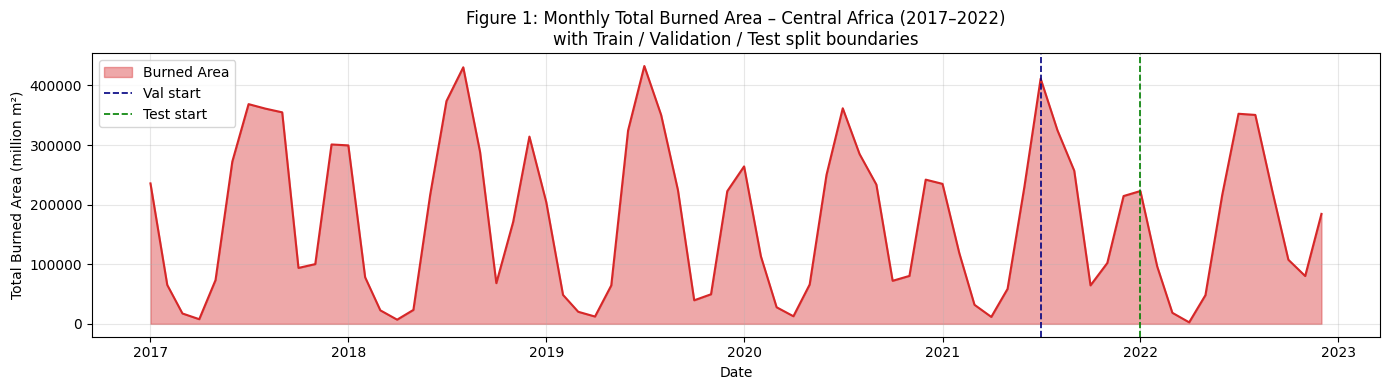

Figure saved to output folder.


In [28]:
# Sum burned area over lat/lon for each time step (monthly total for the region)
monthly_total = ds_masked['burned_area'].sum(dim=['lat', 'lon']).compute()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(pd.to_datetime(monthly_total.time.values),
                monthly_total.values / 1e6,
                alpha=0.4, color='#d62728', label='Burned Area')
ax.plot(pd.to_datetime(monthly_total.time.values),
        monthly_total.values / 1e6,
        color='#d62728', linewidth=1.5)

# Mark the train/val/test boundaries
ax.axvline(pd.Timestamp(ds_val.time.values[0]),  color='navy',  linestyle='--', linewidth=1.2, label='Val start')
ax.axvline(pd.Timestamp(ds_test.time.values[0]), color='green', linestyle='--', linewidth=1.2, label='Test start')

ax.set_xlabel('Date')
ax.set_ylabel('Total Burned Area (million m²)')
ax.set_title('Figure 1: Monthly Total Burned Area – Central Africa (2017–2022)\n'
             'with Train / Validation / Test split boundaries')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig1_monthly_burned_area_timeseries.png'), dpi=150)
plt.show()
print('Figure saved to output folder.')

---
## 11. Save Processed Splits

We save each split as a Zarr store. Zarr is preferred over NetCDF for the pipeline because:
- It supports chunked, parallel reads natively (faster for Dask in Notebooks 3–5)
- Each variable is stored separately, allowing selective loading
- Write speed is significantly faster than NetCDF for large arrays

In [29]:
import os
import xarray as xr

# 1. Define paths (Ensure this folder exists)
OUTPUT_PATH = './processed/' 
os.makedirs(OUTPUT_PATH, exist_ok=True)

# 2. Total Reset Function
def finalize_dataset(ds):
    """
    Clears all encoding and unifies chunks to ensure Zarr compatibility.
    This is essential for the 'Sustainable AI' requirement of efficiency.
    """
    # Remove all original NetCDF metadata that causes conflicts
    for var in ds.variables:
        ds[var].encoding = {}
        
    # Unify chunks: this makes every time-slice a single chunk.
    # This prevents the 'Final chunk size' ValueError.
    return ds.chunk({'time': 1, 'lat': -1, 'lon': -1})

# 3. Save Loop
splits = {
    'train': ds_train,
    'val':   ds_val,
    'test':  ds_test
}

for split_name, split_ds in splits.items():
    save_path = os.path.join(OUTPUT_PATH, f'{split_name}_data.zarr')
    
    # Apply the fix
    ready_ds = finalize_dataset(split_ds)
    
    # Save as Zarr with consolidated metadata for Notebook 2 efficiency
    ready_ds.to_zarr(save_path, mode='w', consolidated=True)
    print(f'Successfully saved {split_name} split to: {save_path}')

print('\n--- Notebook 1: Data Loading & Preprocessing OFFICIALLY COMPLETE ---')

Successfully saved train split to: ./processed/train_data.zarr
Successfully saved val split to: ./processed/val_data.zarr
Successfully saved test split to: ./processed/test_data.zarr

--- Notebook 1: Data Loading & Preprocessing OFFICIALLY COMPLETE ---


---
## Summary of Preprocessing Steps

| Step | Action | Justification |
|------|--------|---------------|
| Region crop | Central Africa (-20°–10°N, 10°–45°E) | Highest global fire density; reduces sparsity |
| Masking | Remove pixels with < 1% burnable area | Removes ocean/ice noise from target variable |
| Feature engineering | month_sin, month_cos | Cyclic encoding of seasonality for LSTM |
| Log transform | log1p(burned_area) | Compresses extreme right skew in fire data |
| Chronological split | 54 / 6 / 12 months | Prevents data leakage in time-series models |
| Normalisation | Min-max fitted on train only | Prevents data leakage into val/test sets |
| Output format | Zarr stores | Efficient chunked I/O for subsequent notebooks |